HUYỀN

KẾT NỐI SQL

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

SERVER_NAME = 'DESKTOP-06I4T19\SQLEXPRESS' # Hoặc 'DESKTOP-06I4T19\SQLEXPRESS'
DATABASE_NAME = 'CarProject'
DRIVER_NAME = 'ODBC Driver 17 for SQL Server'
connection_url = f"mssql+pyodbc://@{SERVER_NAME}/{DATABASE_NAME}?driver={DRIVER_NAME.replace(' ', '+')}&trusted_connection=yes"
engine = create_engine(connection_url)

print("✅ Đồ nghề và kết nối SQL đã sẵn sàng!")

✅ Đồ nghề và kết nối SQL đã sẵn sàng!


ĐƯA DỮ LIỆU VÀO SQL

In [33]:
# 1. Đọc file CSV gốc
df_raw = pd.read_csv('car_price_prediction.csv')

# 2. Đẩy thẳng toàn bộ vào SQL Server thành một bảng tên là 'Cars_Raw'
df_raw.to_sql('Cars_Raw', con=engine, if_exists='replace', index=False)

print("✅ Đã nhập kho dữ liệu thô vào bảng 'Cars_Raw' trong SQL Server.")

✅ Đã nhập kho dữ liệu thô vào bảng 'Cars_Raw' trong SQL Server.


CHỌN FEATURE

In [34]:

sql_query = """
SELECT 
    Price, Levy, Manufacturer, Model, [Prod. year], Category, 
    [Fuel type], [Engine volume], Mileage, [Leather interior],
    Cylinders, [Gear box type], [Drive wheels], 
    Color, Airbags
FROM Cars_Raw

"""

# Thực thi SQL và kéo dữ liệu sạch (đã lọc đáy) về Pandas
df = pd.read_sql_query(sql_query, con=engine)

print(f"✅ Đã dùng truy vấn SQL rút {df.shape[1]} ")
df.head(3)

✅ Đã dùng truy vấn SQL rút 15 


,Price,Levy,Manufacturer,Model,Prod. year,Category,Fuel type,Engine volume,Mileage,Leather interior,Cylinders,Gear box type,Drive wheels,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Hybrid,3.5,186005 km,Yes,6.0,Automatic,4x4,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,Petrol,3,192000 km,No,6.0,Tiptronic,4x4,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,Petrol,1.3,200000 km,No,4.0,Variator,Front,Black,2


XỬ LÍ DỮ LIỆU

In [35]:
# Xử lý cột Mileage (xóa ' km') và điền ô trống bằng Median
df['Mileage'] = df['Mileage'].astype(str).str.replace(' km', '')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)

# Hierarchical Imputation cho cột Levy (Thuế/Phí)
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

# Lớp lưới 1: Nội suy chính xác theo Hãng + Năm + Động cơ + Loại Nhiên liệu
df['Levy'] = df['Levy'].fillna(
    df.groupby(['Manufacturer', 'Prod. year', 'Engine volume', 'Fuel type'])['Levy'].transform('median')
)

# Lớp lưới 2: Nới lỏng - Lấy theo Hãng + Năm sản xuất
df['Levy'] = df['Levy'].fillna(
    df.groupby(['Manufacturer', 'Prod. year'])['Levy'].transform('median')
)

# Lớp lưới 3: Nới lỏng - Lấy theo Phân khúc xe (Category)
df['Levy'] = df['Levy'].fillna(
    df.groupby('Category')['Levy'].transform('median')
)

# Lớp lưới 4: Lưới an toàn cuối cùng - Median toàn cục
df['Levy'] = df['Levy'].fillna(df['Levy'].median())

# === TRÍCH XUẤT TURBO & TUỔI XE TRƯỚC KHI LỌC OUTLIER ===
# 1. Tạo cột 'is_Turbo' và làm sạch cột 'Engine volume'
df['is_Turbo'] = df['Engine volume'].astype(str).str.contains('Turbo', case=False).astype(int)
df['Engine volume'] = df['Engine volume'].astype(str).str.replace(' Turbo', '', case=False).str.strip()
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')

# 2. Chuyển năm sản xuất thành tuổi xe
df['Car_Age'] = 2024 - df['Prod. year']
df.drop('Prod. year', axis=1, inplace=True) # Xóa cột cũ

print("✅ Đã xử lý Missing Values, Levy, is_Turbo và Car_Age!")


✅ Đã xử lý Missing Values, Levy, is_Turbo và Car_Age!


HIẾU

XỬ LÍ OUTLIER

In [36]:
initial_rows = df.shape[0]

df_final = df[
    (df['Price']   >= 1_000)   & (df['Price']   <= 100_000) &
    (df['Mileage'] >= 1_000)   & (df['Mileage'] <= 400_000)
]

final_rows = df_final.shape[0]
print(f"✅ Da loc xong ngoai lai!")
print(f"👉 So dong bi loai: {initial_rows - final_rows:,} dong")
print(f"📉 Gia xe: {df_final['Price'].min():,.0f}$ → {df_final['Price'].max():,.0f}$")
print(f"📏 So km: {df_final['Mileage'].min():,.0f} km → {df_final['Mileage'].max():,.0f} km")
print(f"📊 Con lai: {final_rows:,} dong")


✅ Da loc xong ngoai lai!
👉 So dong bi loai: 3,654 dong
📉 Gia xe: 1,000$ → 99,440$
📏 So km: 1,000 km → 400,000 km
📊 Con lai: 15,583 dong


In [37]:
# Lưu phiên bản đã làm sạch đẹp đẽ thành một bảng mới để bạn số 2 lấy ra dùng
df_final.to_sql('Cars_Cleaned', con=engine, if_exists='replace', index=False)

print("🚀 HOÀN TẤT! Dữ liệu sạch đã nằm trong bảng 'Cars2_Cleaned'. Bàn giao cho Người 2!")

🚀 HOÀN TẤT! Dữ liệu sạch đã nằm trong bảng 'Cars2_Cleaned'. Bàn giao cho Người 2!


TẠO BẢN ĐỒ HÃNG XE-DÒNG XE VÀ CHIA TẬP DỮ LIỆU

In [38]:
# 1. Xử lý phông chữ rác trước (Đổi các ký tự lỗi ??? hoặc tiếng Gruzia thành 'Other')
for col in ['Manufacturer', 'Model']:
    df_final[col] = df_final[col].apply(lambda x: 'Other' if '?' in str(x) or 'სხვა' in str(x) else x)

encoding_dict = {}

# 2. Tạo Bản đồ Hãng xe -> Dòng xe trên toàn bộ dữ liệu (vì không chứa biến mục tiêu Price, không lo leakage)
mfg_model_mapping = df_final.groupby('Manufacturer')['Model'].unique().apply(list).to_dict()
encoding_dict['mfg_model_mapping'] = mfg_model_mapping

# 3. Chia tập dữ liệu thành 80% Train và 20% Test TRƯỚC KHI MÃ HÓA để tránh Data Leakage
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=42)

print("✅ Đã chuẩn bị dữ liệu và chia tập Train/Test thành công!")


✅ Đã chuẩn bị dữ liệu và chia tập Train/Test thành công!


MÃ HÓA DỮ LIỆU

In [39]:
import pickle

# 1. Đảm bảo đủ 8 cột thuộc tính phân loại cần mã hóa
cat_features = ['Manufacturer', 'Model', 'Category', 'Fuel type', 
                'Gear box type', 'Drive wheels', 'Color', 'Leather interior']

# 2. Tính trung bình giá xe trên TẬP TRAIN (Global Mean)
global_mean = train_df['Price'].mean()
encoding_dict['global_mean'] = global_mean

# 3. Tính toán Target Encoding (Mean Encoding) CHỈ dựa trên dữ liệu tập Train
for col in cat_features:
    # Tính toán mean_map trên train_df
    mean_map = train_df.groupby(col)['Price'].mean().to_dict()
    encoding_dict[col] = mean_map
    
    # Ánh xạ lên cả tập Train và tập Test (fillna bằng global_mean của tập Train)
    train_df[col] = train_df[col].map(mean_map).fillna(global_mean)
    test_df[col] = test_df[col].map(mean_map).fillna(global_mean)

# 4. Xuất từ điển mã hóa ra file target_encoders.pkl
with open('target_encoders.pkl', 'wb') as f:
    pickle.dump(encoding_dict, f)

# 5. Xuất tập dữ liệu Train/Test đã được mã hóa ra file CSV
train_df.to_csv('car_price_train_clean.csv', index=False)
test_df.to_csv('car_price_test_clean.csv', index=False)

print("✅ Đã mã hóa dữ liệu tránh Leakage và lưu từ điển thành công!")
print(f"📊 Tập Train: {train_df.shape[0]} dòng (đã lưu vào 'car_price_train_clean.csv')")
print(f"📊 Tập Test: {test_df.shape[0]} dòng (đã lưu vào 'car_price_test_clean.csv')")


✅ Đã mã hóa dữ liệu tránh Leakage và lưu từ điển thành công!
📊 Tập Train: 12466 dòng (đã lưu vào 'car_price_train_clean.csv')
📊 Tập Test: 3117 dòng (đã lưu vào 'car_price_test_clean.csv')


UYÊN

HUẤN LUYỆN MÔ HÌNH

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pickle

# 1. Tách X (tính năng) và y (giá xe) từ tập Train và Test
X_train = train_df.drop('Price', axis=1)
y_train = train_df['Price']
X_test = test_df.drop('Price', axis=1)
y_test = test_df['Price']

# 2. Khởi tạo mô hình Random Forest
# n_estimators=100: dùng 100 cây quyết định để bỏ phiếu
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 3. Cho máy học (Training)
model.fit(X_train, y_train)
with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✅ Đã huấn luyện và lưu mô hình Random Forest vào file 'best_rf_model.pkl'!")



✅ Đã huấn luyện và lưu mô hình Random Forest vào file 'best_rf_model.pkl'!


ĐÁNH GIÁ MÔ HÌNH

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np

y_pred = model.predict(X_test)

mae   = mean_absolute_error(y_test, y_pred)
mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)
r2    = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mape  = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
n     = len(y_test)
p     = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("📊 DANH GIA MO HINH RANDOM FOREST")
print("=" * 45)
print(f"  MAE          : {mae:,.2f} $")
print(f"  MSE          : {mse:,.2f}")
print(f"  RMSE         : {rmse:,.2f} $")
print(f"  Median AE    : {medae:,.2f} $")
print(f"  MAPE         : {mape:.2f} %")
print(f"  R2 Score     : {r2:.4f}")
print(f"  Adjusted R2  : {adj_r2:.4f}")


📊 DANH GIA MO HINH RANDOM FOREST
  MAE          : 4,275.34 $
  MSE          : 59,641,714.10
  RMSE         : 7,722.80 $
  Median AE    : 2,172.46 $
  MAPE         : 44.94 %
  R2 Score     : 0.7520
  Adjusted R2  : 0.7508


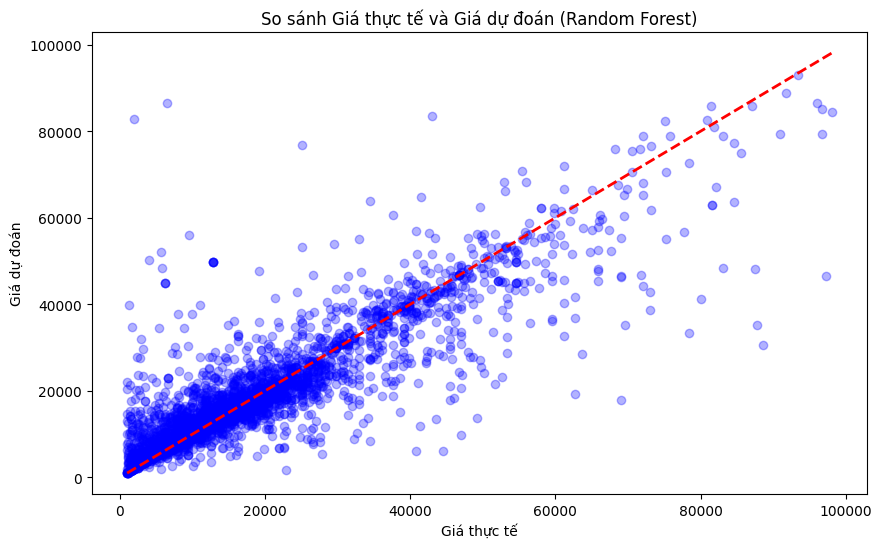

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('So sánh Giá thực tế và Giá dự đoán (Random Forest)')
plt.show()
